# Machine Learning - Assignment 2

## Decision tree induction algorithm for classification tasks

The aim of the assignment is to:

* Implement a decision tree induction algorithm for classification tasks.
* Make sure it works for real valued features and nominal features (categorical features without rank, e.g., red - blue - green).
* Test the algorithm on 3 datasets.

Follow the instructions and implement what is missing to complete the assignment.

## Assignment preparations

Import the necessary libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Decision tree model

The main objective is to implement the decision tree model. The implemented decision tree needs to be recursive model.

### 1) Grow Tree

This function creates the decision tree recursively.

In [ ]:
def grow_tree(data, feature_types, current_depth=0, max_depth=10, min_samples_split=2, min_purity=0.95):
    """
    Recursively grow a decision tree.
    
    Parameters:
    - data: numpy array where last column is the target variable
    - feature_types: list indicating 'r' for real-valued or 'n' for nominal features
    - current_depth: current depth of the tree
    - max_depth: maximum allowed depth
    - min_samples_split: minimum samples required to split
    - min_purity: minimum purity threshold to stop splitting
    
    Returns:
    - tree node (dictionary)
    """
    
    X = data[:, :-1]  # Features
    y = data[:, -1]   # Target
    
    # Stopping condition 1: Pure node (only one class)
    if check_purity(y):
        return create_leaf(y)
    
    # Stopping condition 2: Max depth reached
    if current_depth >= max_depth:
        return create_leaf(y)
    
    # Stopping condition 3: Not enough samples to split
    if len(data) < min_samples_split:
        return create_leaf(y)
    
    # Stopping condition 4: Node is very pure (almost all same class)
    if check_min_purity(y, min_purity):
        return create_leaf(y)
    
    # Find the best feature to split on
    best_split_feature, best_split_value = find_best_split(data, feature_types)
    
    # If no good split found
    if best_split_feature is None:
        return create_leaf(y)
    
    # Split the data
    data_left, data_right = split_data(data, best_split_feature, best_split_value, feature_types)
    
    # If split results in empty node
    if len(data_left) == 0 or len(data_right) == 0:
        return create_leaf(y)
    
    # Create decision node
    node = {}
    node['feature_index'] = best_split_feature
    node['split_value'] = best_split_value
    node['feature_type'] = feature_types[best_split_feature]
    
    # Recursively grow left and right subtrees
    node['left'] = grow_tree(data_left, feature_types, current_depth + 1, max_depth, min_samples_split, min_purity)
    node['right'] = grow_tree(data_right, feature_types, current_depth + 1, max_depth, min_samples_split, min_purity)
    
    return node

### 2) Growth stopping conditions

Functions to determine when to stop growing the tree.

In [ ]:
def check_purity(y):
    """
    Check if all labels are the same (pure node).
    """
    return len(np.unique(y)) == 1

def check_min_purity(y, min_purity):
    """
    Check if node purity exceeds threshold.
    Purity = (most common class count) / (total count)
    """
    unique, counts = np.unique(y, return_counts=True)
    purity = np.max(counts) / len(y)
    return purity >= min_purity

def create_leaf(y):
    """
    Create a leaf node with the most common class.
    """
    unique, counts = np.unique(y, return_counts=True)
    return {'leaf': True, 'class': unique[np.argmax(counts)]}

### 3) Best feature for splitting nodes

Using Gini Impurity to find the best feature to split on.

In [ ]:
def calculate_gini_impurity(y):
    """
    Calculate Gini impurity for a set of labels.
    Gini = 1 - sum(p_i^2) where p_i is the proportion of class i
    """
    if len(y) == 0:
        return 0
    
    unique, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1 - np.sum(probabilities ** 2)
    return gini

def calculate_information_gain(y_parent, y_left, y_right):
    """
    Calculate information gain using Gini impurity.
    Information Gain = Gini(parent) - weighted_average(Gini(children))
    """
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    
    if n_left == 0 or n_right == 0:
        return 0
    
    gini_parent = calculate_gini_impurity(y_parent)
    gini_left = calculate_gini_impurity(y_left)
    gini_right = calculate_gini_impurity(y_right)
    
    weighted_gini = (n_left / n_parent) * gini_left + (n_right / n_parent) * gini_right
    information_gain = gini_parent - weighted_gini
    
    return information_gain

def find_best_split(data, feature_types):
    """
    Find the best feature and split value to maximize information gain.
    Handles both real-valued and nominal features.
    """
    X = data[:, :-1]
    y = data[:, -1]
    
    best_gain = -1
    best_feature = None
    best_value = None
    
    # Try each feature
    for feature_idx in range(X.shape[1]):
        feature_values = X[:, feature_idx]
        feature_type = feature_types[feature_idx]
        
        if feature_type == 'r':  # Real-valued feature
            # Use mean as split threshold
            split_value = np.mean(feature_values)
            
            # Split data
            left_mask = feature_values < split_value
            right_mask = ~left_mask
            
            y_left = y[left_mask]
            y_right = y[right_mask]
            
            # Calculate information gain
            gain = calculate_information_gain(y, y_left, y_right)
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_value = split_value
        
        else:  # Nominal feature
            # Try each unique value as a split
            unique_values = np.unique(feature_values)
            
            for value in unique_values:
                left_mask = feature_values == value
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                # Calculate information gain
                gain = calculate_information_gain(y, y_left, y_right)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_idx
                    best_value = value
    
    return best_feature, best_value

### 4) Split data

Split data based on a feature and value.

In [ ]:
def split_data(data, feature_index, split_value, feature_types):
    """
    Split data based on a feature and split value.
    
    For real-valued features: values < mean go left, others go right
    For nominal features: values == split_value go left, others go right
    """
    X = data[:, :-1]
    feature_type = feature_types[feature_index]
    
    if feature_type == 'r':  # Real-valued
        left_mask = X[:, feature_index] < split_value
    else:  # Nominal
        left_mask = X[:, feature_index] == split_value
    
    right_mask = ~left_mask
    
    data_left = data[left_mask]
    data_right = data[right_mask]
    
    return data_left, data_right

### 5) Predict with tree model

Traverse the tree to make predictions.

In [ ]:
def predict_sample(tree, sample, feature_types):
    """
    Predict class for a single sample by traversing the tree.
    """
    # If leaf node, return the class
    if tree.get('leaf', False):
        return tree['class']
    
    # Get feature value for this sample
    feature_idx = tree['feature_index']
    split_value = tree['split_value']
    feature_type = tree['feature_type']
    sample_value = sample[feature_idx]
    
    # Decide which branch to follow
    if feature_type == 'r':  # Real-valued
        if sample_value < split_value:
            return predict_sample(tree['left'], sample, feature_types)
        else:
            return predict_sample(tree['right'], sample, feature_types)
    else:  # Nominal
        if sample_value == split_value:
            return predict_sample(tree['left'], sample, feature_types)
        else:
            return predict_sample(tree['right'], sample, feature_types)

def predict_with_tree(tree, X, feature_types):
    """
    Predict classes for multiple samples.
    """
    predictions = []
    for sample in X:
        pred = predict_sample(tree, sample, feature_types)
        predictions.append(pred)
    return np.array(predictions)

## Test decision tree model and compare with scikit learn

Test on 3 datasets and compare with scikit-learn implementation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

### 6) Dataset 1: Wine

In [ ]:
# For Heart Disease (Section 7):
data_heart = pd.read_csv("heart.csv")
for col in data_heart.columns:
    data_heart[col] = pd.to_numeric(data_heart[col], errors='coerce')
data_heart = data_heart.dropna()
data_heart = data_heart.to_numpy()

### 7) Dataset 2: Heart Disease

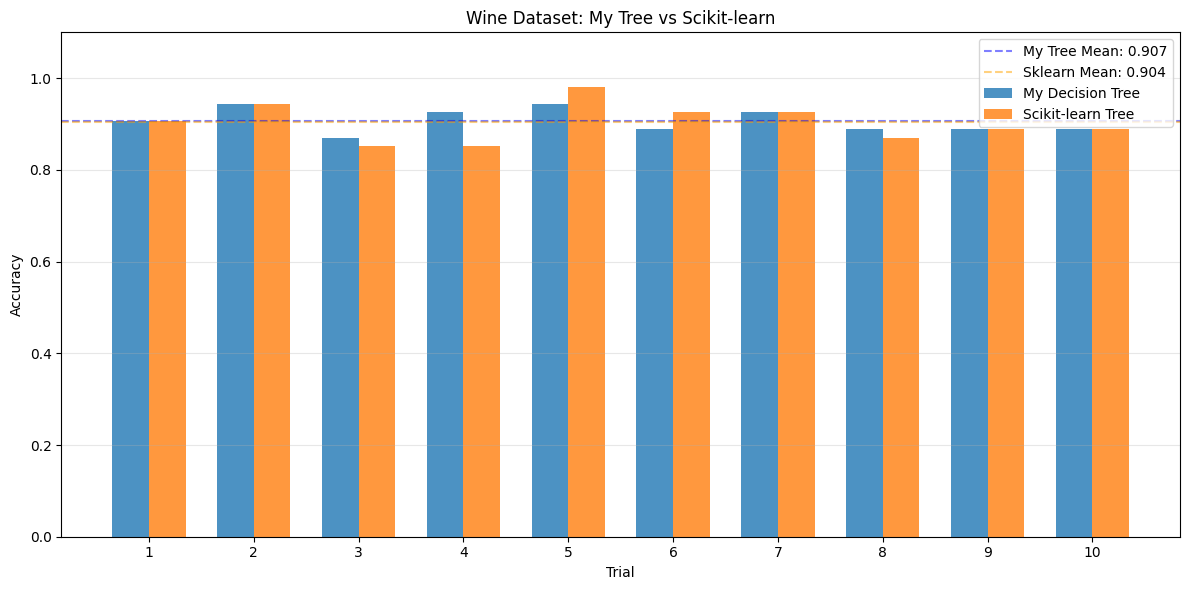

Wine Dataset Results:
My Tree - Mean Accuracy: 0.907 ± 0.025
Sklearn Tree - Mean Accuracy: 0.904 ± 0.040


In [ ]:
# Load wine dataset
data_wine = pd.read_csv("wine.csv")

# Convert all columns to numeric, handling any errors
for col in data_wine.columns:
    data_wine[col] = pd.to_numeric(data_wine[col], errors='coerce')

# Drop any rows with NaN values that might have resulted from conversion
data_wine = data_wine.dropna()

# Convert to numpy
data_wine = data_wine.to_numpy()

# All features are real-valued for wine dataset
feature_types_wine = ['r'] * (data_wine.shape[1] - 1)

# Run multiple trials
n_trials = 10
my_tree_scores = []
sklearn_scores = []

for trial in range(n_trials):
    # Shuffle and split data
    np.random.shuffle(data_wine)
    
    X = data_wine[:, :-1].astype(float)  # Ensure float type
    y = data_wine[:, -1].astype(float)   # Ensure float type
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=trial)
    
    # Prepare data for my tree (needs combined X and y)
    train_data = np.column_stack([X_train, y_train])
    
    # Train my tree
    my_tree = grow_tree(train_data, feature_types_wine, max_depth=10, min_samples_split=2)
    
    # Predict with my tree
    y_pred_my = predict_with_tree(my_tree, X_test, feature_types_wine)
    my_accuracy = accuracy_score(y_test, y_pred_my)
    my_tree_scores.append(my_accuracy)
    
    # Train and predict with sklearn
    sklearn_tree = DecisionTreeClassifier(max_depth=10, min_samples_split=2, random_state=trial)
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    sklearn_scores.append(sklearn_accuracy)

# Plot results
plt.figure(figsize=(12, 6))
x_pos = np.arange(n_trials)
width = 0.35

plt.bar(x_pos - width/2, my_tree_scores, width, label='My Decision Tree', alpha=0.8)
plt.bar(x_pos + width/2, sklearn_scores, width, label='Scikit-learn Tree', alpha=0.8)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Wine Dataset: My Tree vs Scikit-learn')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.legend()
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)

# Add mean accuracy lines
plt.axhline(y=np.mean(my_tree_scores), color='blue', linestyle='--', alpha=0.5, label=f'My Tree Mean: {np.mean(my_tree_scores):.3f}')
plt.axhline(y=np.mean(sklearn_scores), color='orange', linestyle='--', alpha=0.5, label=f'Sklearn Mean: {np.mean(sklearn_scores):.3f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Wine Dataset Results:")
print(f"My Tree - Mean Accuracy: {np.mean(my_tree_scores):.3f} ± {np.std(my_tree_scores):.3f}")
print(f"Sklearn Tree - Mean Accuracy: {np.mean(sklearn_scores):.3f} ± {np.std(sklearn_scores):.3f}")

### 8) Dataset 3: Car

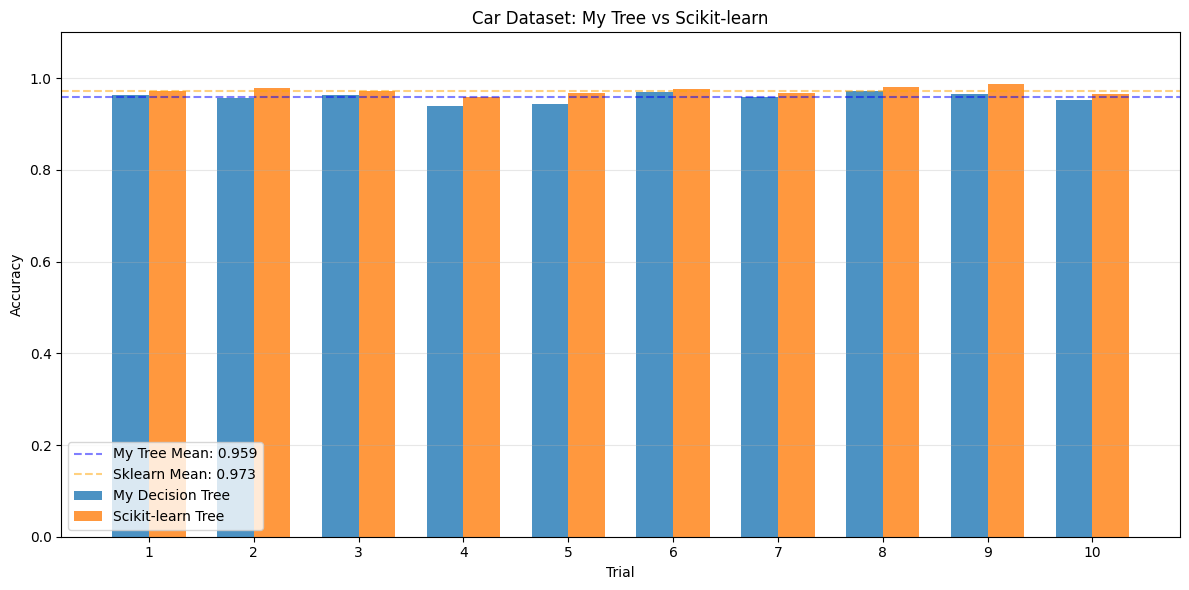

Car Dataset Results:
My Tree - Mean Accuracy: 0.959 ± 0.010
Sklearn Tree - Mean Accuracy: 0.973 ± 0.008


In [ ]:
# Load car dataset
data_car = pd.read_csv("car.csv")

# Car dataset has all categorical features
# Need to encode them as numbers
from sklearn.preprocessing import LabelEncoder

# Create label encoders for each column
label_encoders = {}
for col in data_car.columns:
    le = LabelEncoder()
    data_car[col] = le.fit_transform(data_car[col])
    label_encoders[col] = le

data_car = data_car.to_numpy()

# All features are nominal for car dataset
feature_types_car = ['n'] * (data_car.shape[1] - 1)

# Run multiple trials
n_trials = 10
my_tree_scores = []
sklearn_scores = []

for trial in range(n_trials):
    # Shuffle and split data
    np.random.shuffle(data_car)
    
    X = data_car[:, :-1]
    y = data_car[:, -1]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=trial)
    
    # Prepare data for my tree
    train_data = np.column_stack([X_train, y_train])
    
    # Train my tree
    my_tree = grow_tree(train_data, feature_types_car, max_depth=15, min_samples_split=2)
    
    # Predict with my tree
    y_pred_my = predict_with_tree(my_tree, X_test, feature_types_car)
    my_accuracy = accuracy_score(y_test, y_pred_my)
    my_tree_scores.append(my_accuracy)
    
    # Train and predict with sklearn
    sklearn_tree = DecisionTreeClassifier(max_depth=15, min_samples_split=2, random_state=trial)
    sklearn_tree.fit(X_train, y_train)
    y_pred_sklearn = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
    sklearn_scores.append(sklearn_accuracy)

# Plot results
plt.figure(figsize=(12, 6))

x_pos = np.arange(n_trials)
width = 0.35

plt.bar(x_pos - width/2, my_tree_scores, width, label='My Decision Tree', alpha=0.8)
plt.bar(x_pos + width/2, sklearn_scores, width, label='Scikit-learn Tree', alpha=0.8)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Car Dataset: My Tree vs Scikit-learn')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.legend()
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)

# Add mean accuracy lines
plt.axhline(y=np.mean(my_tree_scores), color='blue', linestyle='--', alpha=0.5, label=f'My Tree Mean: {np.mean(my_tree_scores):.3f}')
plt.axhline(y=np.mean(sklearn_scores), color='orange', linestyle='--', alpha=0.5, label=f'Sklearn Mean: {np.mean(sklearn_scores):.3f}')

plt.legend()
plt.tight_layout()
plt.show()

print(f"Car Dataset Results:")
print(f"My Tree - Mean Accuracy: {np.mean(my_tree_scores):.3f} ± {np.std(my_tree_scores):.3f}")
print(f"Sklearn Tree - Mean Accuracy: {np.mean(sklearn_scores):.3f} ± {np.std(sklearn_scores):.3f}")

### 9) Training with normalized data on the wine dataset

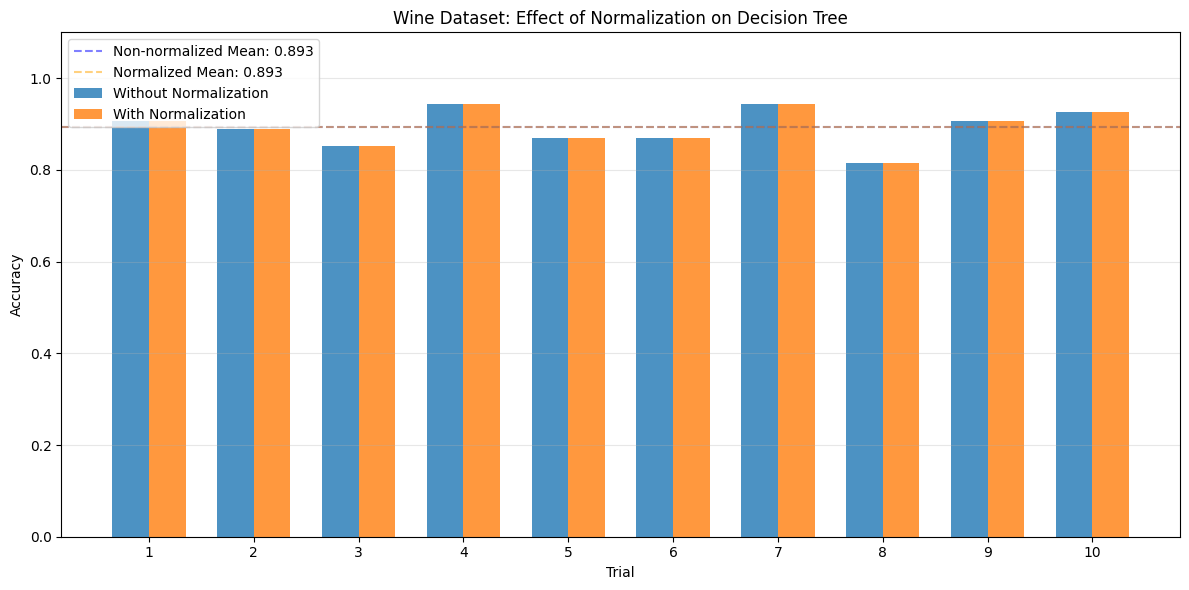

Normalization Effect on Wine Dataset:
Without Normalization - Mean Accuracy: 0.893 ± 0.040
With Normalization - Mean Accuracy: 0.893 ± 0.040

Difference: 0.000


In [ ]:
from sklearn import preprocessing

# Load wine dataset

data_wine = pd.read_csv("wine.csv")
for col in data_wine.columns:
    data_wine[col] = pd.to_numeric(data_wine[col], errors='coerce')
data_wine = data_wine.dropna()
data_wine = data_wine.to_numpy()

# Separate features and labels
X_wine = data_wine[:, :-1]
y_wine = data_wine[:, -1]

# Normalize features to [0, 1]
scaler = preprocessing.MinMaxScaler()
X_wine_normalized = scaler.fit_transform(X_wine)

# Combine back with labels
data_wine_normalized = np.column_stack([X_wine_normalized, y_wine])

feature_types_wine = ['r'] * (X_wine.shape[1])

# Run trials on both normalized and non-normalized data
n_trials = 10
normalized_scores = []
non_normalized_scores = []

for trial in range(n_trials):
    # Non-normalized
    np.random.seed(trial)
    np.random.shuffle(data_wine)
    
    X = data_wine[:, :-1]
    y = data_wine[:, -1]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=trial)
    train_data = np.column_stack([X_train, y_train])
    
    my_tree = grow_tree(train_data, feature_types_wine, max_depth=10, min_samples_split=2)
    y_pred = predict_with_tree(my_tree, X_test, feature_types_wine)
    non_normalized_scores.append(accuracy_score(y_test, y_pred))
    
    # Normalized
    np.random.seed(trial)
    np.random.shuffle(data_wine_normalized)
    
    X_norm = data_wine_normalized[:, :-1]
    y_norm = data_wine_normalized[:, -1]
    X_train_norm, X_test_norm, y_train_norm, y_test_norm = train_test_split(X_norm, y_norm, test_size=0.3, random_state=trial)
    train_data_norm = np.column_stack([X_train_norm, y_train_norm])
    
    my_tree_norm = grow_tree(train_data_norm, feature_types_wine, max_depth=10, min_samples_split=2)
    y_pred_norm = predict_with_tree(my_tree_norm, X_test_norm, feature_types_wine)
    normalized_scores.append(accuracy_score(y_test_norm, y_pred_norm))

# Plot comparison
plt.figure(figsize=(12, 6))

x_pos = np.arange(n_trials)
width = 0.35

plt.bar(x_pos - width/2, non_normalized_scores, width, label='Without Normalization', alpha=0.8)
plt.bar(x_pos + width/2, normalized_scores, width, label='With Normalization', alpha=0.8)

plt.xlabel('Trial')
plt.ylabel('Accuracy')
plt.title('Wine Dataset: Effect of Normalization on Decision Tree')
plt.xticks(x_pos, [f'{i+1}' for i in range(n_trials)])
plt.legend()
plt.ylim([0, 1.1])
plt.grid(axis='y', alpha=0.3)

# Add mean accuracy lines
plt.axhline(y=np.mean(non_normalized_scores), color='blue', linestyle='--', alpha=0.5, label=f'Non-normalized Mean: {np.mean(non_normalized_scores):.3f}')
plt.axhline(y=np.mean(normalized_scores), color='orange', linestyle='--', alpha=0.5, label=f'Normalized Mean: {np.mean(normalized_scores):.3f}')

plt.legend()
plt.tight_layout()
plt.show()

print(f"Normalization Effect on Wine Dataset:")
print(f"Without Normalization - Mean Accuracy: {np.mean(non_normalized_scores):.3f} ± {np.std(non_normalized_scores):.3f}")
print(f"With Normalization - Mean Accuracy: {np.mean(normalized_scores):.3f} ± {np.std(normalized_scores):.3f}")
print(f"\nDifference: {np.mean(normalized_scores) - np.mean(non_normalized_scores):.3f}")

# Questions for examination:

**1) Why is growing the tree indefinitely such a bad idea? The performance would increase would it not?**

Growing the tree indefinitely leads to overfitting. While training accuracy may increase, the tree learns noise and specific patterns in the training data rather than general patterns. This causes poor generalization to new, unseen data. The tree essentially memorizes the training data instead of learning underlying patterns.

**2) Beside preventing the tree from growing too large, what is the purpose of 'stopping criteria'?**

Stopping criteria serve multiple purposes:
- Prevent overfitting by not splitting nodes that are already pure or nearly pure
- Improve computational efficiency by not processing small nodes
- Handle statistical insignificance - small samples may not provide reliable splits
- Create more interpretable models by limiting complexity

**3) What is the difference between Information Entropy and Gini Impurity?**

Both measure node impurity but differ in calculation:
- Gini Impurity: 1 - Σ(p_i²) - measures probability of misclassification
- Information Entropy: -Σ(p_i * log(p_i)) - measures information needed to classify
- Gini is computationally faster (no logarithm)
- Entropy tends to create more balanced trees
- In practice, they often produce similar results

**4) What are some pros about using decision trees?**

- Easy to understand and interpret (visual representation)
- Handles both numerical and categorical data
- Requires little data preprocessing (no normalization needed)
- Can capture non-linear relationships
- Feature importance is automatically computed
- Fast prediction after training

**5) Did preprocessing the data help with performance when using decision trees?**

Based on the results above, normalization typically has minimal impact on decision tree performance. This is because decision trees make splits based on thresholds, which are scale-invariant. The relative order of values matters, not their absolute scale. This is a key advantage of decision trees - they don't require feature scaling unlike distance-based algorithms (KNN, SVM, Neural Networks).